# 03. HMM + Viterbi

This notebook is dedicated to a single POS-tagging model: **HMM + Viterbi**.

It contains:
- the minimal benchmark-loading utilities
- the implementation of this model only
- shared evaluation helpers
- one training/evaluation run
- inline plots and error analysis for this model


## Model Role

A probabilistic sequence baseline with transition/emission statistics and Viterbi decoding.

Keeping one model per notebook makes the experiments easier to run, inspect, and rerun independently.


In [1]:
from pathlib import Path
import time

from tqdm import tqdm


## Minimal Benchmark Utilities

The notebook reloads the benchmark directly from `data/raw/`, so it does not depend on precomputed artifacts.


In [2]:
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
from conllu import parse_incr


# Fixed raw filenames for the shared UD English EWT benchmark.
RAW_FILENAMES = {
    'train': 'en_ewt-ud-train.conllu',
    'dev': 'en_ewt-ud-dev.conllu',
    'test': 'en_ewt-ud-test.conllu',
}


@dataclass
class SentenceRecord:
    sentence_id: str
    tokens: list[str]
    tags: list[str]
    metadata: dict[str, Any]


def set_seed(seed: int = 13) -> None:
    # Keep randomization stable across Python, NumPy, and Torch runs.
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def normalize_neural_token(token: str) -> str:
    # Light normalization is only used by the neural model vocabulary.
    if token.isdigit():
        return '<NUM>'
    if any(char.isdigit() for char in token):
        return '<HASDIGIT>'
    return token.lower()


def load_conllu_sentences(path: str | Path, tag_field: str = 'upostag') -> list[SentenceRecord]:
    path_obj = Path(path)
    sentences: list[SentenceRecord] = []
    with path_obj.open('r', encoding='utf-8') as handle:
        for sentence_index, tokenlist in enumerate(parse_incr(handle)):
            tokens, tags = [], []
            for token in tokenlist:
                token_id = token.get('id')
                if not isinstance(token_id, int):
                    continue
                surface = token.get('form')
                tag = token.get(tag_field)
                if surface is None or tag is None:
                    continue
                tokens.append(str(surface))
                tags.append(str(tag))
            if not tokens:
                continue
            sentences.append(
                SentenceRecord(
                    sentence_id=tokenlist.metadata.get('sent_id', f'{path_obj.stem}-{sentence_index:05d}'),
                    tokens=tokens,
                    tags=tags,
                    metadata=dict(tokenlist.metadata),
                )
            )
    return sentences


def build_vocabulary(
    sentences: list[SentenceRecord],
    lowercase: bool = False,
    normalize: bool = False,
) -> Counter[str]:
    vocab: Counter[str] = Counter()
    for sentence in sentences:
        for token in sentence.tokens:
            key = normalize_neural_token(token) if normalize else token.lower() if lowercase else token
            vocab[key] += 1
    return vocab


def get_label_set(sentences: list[SentenceRecord]) -> list[str]:
    return sorted({tag for sentence in sentences for tag in sentence.tags})


def sentence_oov_rate(tokens: list[str], train_vocabulary: set[str]) -> float:
    if not tokens:
        return 0.0
    return sum(token not in train_vocabulary for token in tokens) / len(tokens)


def split_statistics(
    name: str,
    sentences: list[SentenceRecord],
    train_vocabulary: set[str] | None = None,
) -> dict[str, Any]:
    lengths = [len(sentence.tokens) for sentence in sentences]
    token_total = sum(lengths)
    tag_counter = Counter(tag for sentence in sentences for tag in sentence.tags)
    vocabulary = {token for sentence in sentences for token in sentence.tokens}
    stats: dict[str, Any] = {
        'split': name,
        'num_sentences': len(sentences),
        'num_tokens': token_total,
        'avg_sentence_length': round(float(np.mean(lengths)), 3),
        'median_sentence_length': round(float(np.median(lengths)), 3),
        'max_sentence_length': max(lengths),
        'vocabulary_size': len(vocabulary),
        'num_tags': len(tag_counter),
    }
    if train_vocabulary is not None:
        oov_rates = [sentence_oov_rate(sentence.tokens, train_vocabulary) for sentence in sentences]
        flat_oov = sum(token not in train_vocabulary for sentence in sentences for token in sentence.tokens)
        stats['token_oov_rate'] = round(flat_oov / token_total, 5)
        stats['avg_sentence_oov_rate'] = round(float(np.mean(oov_rates)), 5)
    return stats


def load_benchmark(raw_dir: str | Path = 'data/raw', tag_field: str = 'upostag') -> dict[str, list[SentenceRecord]]:
    raw_dir_path = Path(raw_dir)
    return {
        split: load_conllu_sentences(raw_dir_path / filename, tag_field=tag_field)
        for split, filename in RAW_FILENAMES.items()
    }


## Base Tagger Interface


In [3]:
import pickle
from abc import ABC, abstractmethod
from typing import Iterable


# The benchmark only needs a tiny shared interface: fit, predict, and size.
class BaseSequenceTagger(ABC):
    name: str = 'base'

    @abstractmethod
    def fit(self, train_data: list[SentenceRecord], dev_data: list[SentenceRecord] | None = None) -> None:
        """Train the tagger."""

    @abstractmethod
    def predict(self, dataset: Iterable[SentenceRecord]) -> list[list[str]]:
        """Predict a tag sequence for each sentence."""

    def get_model_size_bytes(self) -> int:
        return len(pickle.dumps(self))


## HMM + Viterbi Implementation


In [4]:
import math
from collections import Counter, defaultdict
from typing import Iterable



class HMMTagger(BaseSequenceTagger):
    name = "hmm_viterbi"

    def __init__(self, transition_alpha: float = 0.1, emission_alpha: float = 0.1, rare_threshold: int = 1) -> None:
        self.transition_alpha = transition_alpha
        self.emission_alpha = emission_alpha
        self.rare_threshold = rare_threshold
        self.labels: list[str] = []
        self.tag_counts: Counter[str] = Counter()
        self.transition_counts: dict[str, Counter[str]] = defaultdict(Counter)
        self.emission_counts: dict[str, Counter[str]] = defaultdict(Counter)
        self.word_counts: Counter[str] = Counter()
        self.unk_tag_counts: Counter[str] = Counter()
        self.suffix_tag_counts: dict[str, Counter[str]] = defaultdict(Counter)
        self.vocabulary: set[str] = set()

    def fit(
        self,
        train_data: list[SentenceRecord],
        dev_data: list[SentenceRecord] | None = None,
    ) -> None:
        del dev_data
        self.labels = sorted({tag for sentence in train_data for tag in sentence.tags})
        self.word_counts = Counter(token for sentence in train_data for token in sentence.tokens)
        self.vocabulary = set(self.word_counts.keys())

        for sentence in train_data:
            prev = "<START>"
            for token, tag in zip(sentence.tokens, sentence.tags):
                self.tag_counts[tag] += 1
                self.transition_counts[prev][tag] += 1
                self.emission_counts[tag][token] += 1
                prev = tag
            self.transition_counts[prev]["<END>"] += 1

        for tag, counter in self.emission_counts.items():
            for word, count in counter.items():
                if self.word_counts[word] <= self.rare_threshold:
                    self.unk_tag_counts[tag] += count
                    lower = word.lower()
                    for size in (1, 2, 3, 4):
                        suffix = lower[-size:]
                        self.suffix_tag_counts[suffix][tag] += count

    def _transition_log_prob(self, prev: str, current: str) -> float:
        num_states = len(self.labels) + 1
        total = sum(self.transition_counts[prev].values())
        count = self.transition_counts[prev][current]
        probability = (count + self.transition_alpha) / (total + self.transition_alpha * num_states)
        return math.log(probability)

    def _unknown_emission_prob(self, tag: str, word: str) -> float:
        vocab_size = len(self.vocabulary) + 1
        base = (self.unk_tag_counts[tag] + self.emission_alpha) / (
            self.tag_counts[tag] + self.emission_alpha * vocab_size
        )
        lower = word.lower()
        suffix_scores = []
        for size in (4, 3, 2, 1):
            suffix = lower[-size:]
            if suffix in self.suffix_tag_counts:
                counter = self.suffix_tag_counts[suffix]
                total = sum(counter.values())
                suffix_scores.append(
                    (counter[tag] + self.emission_alpha) / (total + self.emission_alpha * len(self.labels))
                )
        if suffix_scores:
            return 0.35 * base + 0.65 * max(suffix_scores)
        return base

    def _emission_log_prob(self, tag: str, word: str) -> float:
        vocab_size = len(self.vocabulary) + 1
        if word in self.vocabulary:
            probability = (self.emission_counts[tag][word] + self.emission_alpha) / (
                self.tag_counts[tag] + self.emission_alpha * vocab_size
            )
            return math.log(probability)
        return math.log(self._unknown_emission_prob(tag, word))

    def predict_sentence(self, tokens: list[str]) -> list[str]:
        if not tokens:
            return []
        viterbi: list[dict[str, float]] = []
        backpointers: list[dict[str, str]] = []

        first_scores: dict[str, float] = {}
        first_backpointer: dict[str, str] = {}
        for tag in self.labels:
            first_scores[tag] = self._transition_log_prob("<START>", tag) + self._emission_log_prob(tag, tokens[0])
            first_backpointer[tag] = "<START>"
        viterbi.append(first_scores)
        backpointers.append(first_backpointer)

        for position in range(1, len(tokens)):
            current_scores: dict[str, float] = {}
            current_backpointers: dict[str, str] = {}
            word = tokens[position]
            for current_tag in self.labels:
                emission = self._emission_log_prob(current_tag, word)
                best_prev_tag = ""
                best_score = float("-inf")
                for prev_tag in self.labels:
                    score = (
                        viterbi[position - 1][prev_tag]
                        + self._transition_log_prob(prev_tag, current_tag)
                        + emission
                    )
                    if score > best_score:
                        best_score = score
                        best_prev_tag = prev_tag
                current_scores[current_tag] = best_score
                current_backpointers[current_tag] = best_prev_tag
            viterbi.append(current_scores)
            backpointers.append(current_backpointers)

        last_tag = max(
            self.labels,
            key=lambda tag: viterbi[-1][tag] + self._transition_log_prob(tag, "<END>"),
        )
        tags = [last_tag]
        for position in range(len(tokens) - 1, 0, -1):
            last_tag = backpointers[position][last_tag]
            tags.append(last_tag)
        tags.reverse()
        return tags

    def predict(self, dataset: Iterable[SentenceRecord]) -> list[list[str]]:
        return [self.predict_sentence(sentence.tokens) for sentence in dataset]


## Shared Evaluation Helpers


In [5]:
import time
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


# Buckets are intentionally coarse so the plots stay readable.
LENGTH_BUCKETS = [('1-10', 1, 10), ('11-20', 11, 20), ('21-30', 21, 30), ('31+', 31, None)]
OOV_BUCKETS = [('0%', 0.0, 0.0), ('low', 0.0, 0.1), ('medium', 0.1, 0.3), ('high', 0.3, None)]


def flatten(nested: list[list[str]]) -> list[str]:
    return [item for sublist in nested for item in sublist]


def bucket_by_length(length: int) -> str:
    for label, start, end in LENGTH_BUCKETS:
        if (end is None and length >= start) or (end is not None and start <= length <= end):
            return label
    return 'unknown'


def bucket_by_oov_rate(rate: float) -> str:
    for label, start, end in OOV_BUCKETS:
        if label == '0%' and rate == 0.0:
            return label
        if (end is None and rate > start) or (end is not None and start < rate <= end):
            return label
    return '0%'


def top_confusions(cm: np.ndarray, labels: list[str], limit: int = 15) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for i, gold in enumerate(labels):
        for j, predicted in enumerate(labels):
            if i != j and cm[i, j] > 0:
                rows.append({'gold_tag': gold, 'predicted_tag': predicted, 'count': int(cm[i, j])})
    rows.sort(key=lambda row: row['count'], reverse=True)
    return rows[:limit]


def grouped_sentence_metrics(
    dataset: list[SentenceRecord],
    predictions: list[list[str]],
    train_vocabulary: set[str],
) -> tuple[pd.DataFrame, pd.DataFrame, list[dict[str, Any]]]:
    # Aggregate errors both by sentence length and by OOV pressure.
    length_rows, oov_rows, error_examples = [], [], []
    for sentence, predicted_tags in zip(dataset, predictions):
        token_total = len(sentence.tags)
        correct = sum(gold == pred for gold, pred in zip(sentence.tags, predicted_tags))
        oov_rate = sentence_oov_rate(sentence.tokens, train_vocabulary)
        length_bucket = bucket_by_length(len(sentence.tokens))
        oov_bucket = bucket_by_oov_rate(oov_rate)
        length_rows.append({'bucket': length_bucket, 'correct': correct, 'total': token_total})
        oov_rows.append({'bucket': oov_bucket, 'correct': correct, 'total': token_total})
        if correct < token_total:
            mismatches = [
                {'token': token, 'gold': gold, 'pred': pred}
                for token, gold, pred in zip(sentence.tokens, sentence.tags, predicted_tags)
                if gold != pred
            ]
            error_examples.append({
                'sentence_id': sentence.sentence_id,
                'tokens': sentence.tokens,
                'gold_tags': sentence.tags,
                'predicted_tags': predicted_tags,
                'oov_rate': round(oov_rate, 4),
                'length_bucket': length_bucket,
                'oov_bucket': oov_bucket,
                'mismatches': mismatches,
            })
    length_df = pd.DataFrame(length_rows).groupby('bucket', as_index=False).sum()
    oov_df = pd.DataFrame(oov_rows).groupby('bucket', as_index=False).sum()
    for frame in (length_df, oov_df):
        frame['accuracy'] = frame['correct'] / frame['total']
        frame['error_rate'] = 1.0 - frame['accuracy']
    error_examples.sort(key=lambda row: len(row['mismatches']), reverse=True)
    return length_df, oov_df, error_examples[:30]


## Experiment Configuration


In [6]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'

SEED = 13
TAG_FIELD = 'upostag'
RUN_TEST = True
MODEL_NAME = 'hmm_viterbi'
MODEL_TITLE = 'HMM + Viterbi'
MODEL_DESCRIPTION = "A probabilistic sequence baseline with transition/emission statistics and Viterbi decoding."


def build_benchmark_in_memory(raw_dir: str | Path = 'data/raw', tag_field: str = 'upostag') -> dict[str, Any]:
    dataset = load_benchmark(raw_dir=raw_dir, tag_field=tag_field)
    train_vocab = set(build_vocabulary(dataset['train']).keys())
    stats = {
        split: split_statistics(split, sentences, train_vocabulary=train_vocab if split != 'train' else None)
        for split, sentences in dataset.items()
    }
    return {'dataset': dataset, 'stats': stats, 'train_vocabulary': train_vocab, 'labels': get_label_set(dataset['train'])}


def evaluate_predictions_inline(
    model_name: str,
    dataset: list[SentenceRecord],
    predictions: list[list[str]],
    labels: list[str],
    train_vocabulary: set[str],
    split_name: str,
    train_time_s: float | None = None,
    inference_time_s: float | None = None,
    model_size_bytes: int | None = None,
) -> dict[str, Any]:
    gold = flatten([sentence.tags for sentence in dataset])
    pred = flatten(predictions)
    accuracy = sum(g == p for g, p in zip(gold, pred)) / max(len(gold), 1)
    precision, recall, f1, support = precision_recall_fscore_support(gold, pred, labels=labels, zero_division=0)
    cm = confusion_matrix(gold, pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    length_df, oov_df, error_examples = grouped_sentence_metrics(dataset, predictions, train_vocabulary)
    per_tag_df = pd.DataFrame({'tag': labels, 'precision': precision, 'recall': recall, 'f1': f1, 'support': support}).sort_values(by='f1', ascending=False)
    metrics = {
        'model': model_name,
        'split': split_name,
        'token_accuracy': round(float(accuracy), 6),
        'macro_f1': round(float(np.mean(f1)), 6),
        'train_time_s': None if train_time_s is None else round(float(train_time_s), 4),
        'inference_time_s': None if inference_time_s is None else round(float(inference_time_s), 4),
        'tokens_per_second': None if not inference_time_s else round(len(gold) / inference_time_s, 2),
        'model_size_mb': None if model_size_bytes is None else round(model_size_bytes / (1024 * 1024), 4),
        'num_sentences': len(dataset),
        'num_tokens': len(gold),
    }
    return {
        'metrics': metrics,
        'per_tag_df': per_tag_df,
        'confusion_matrix_df': cm_df,
        'top_confusions_df': pd.DataFrame(top_confusions(cm, labels)),
        'length_df': length_df,
        'oov_df': oov_df,
        'error_examples_df': pd.DataFrame(error_examples),
    }


def evaluate_model_inline(
    tagger: BaseSequenceTagger,
    dataset: list[SentenceRecord],
    labels: list[str],
    train_vocabulary: set[str],
    split_name: str,
    train_time_s: float | None = None,
) -> dict[str, Any]:
    start = time.perf_counter()
    predictions = tagger.predict(dataset)
    inference_time_s = time.perf_counter() - start
    return evaluate_predictions_inline(
        model_name=tagger.name,
        dataset=dataset,
        predictions=predictions,
        labels=labels,
        train_vocabulary=train_vocabulary,
        split_name=split_name,
        train_time_s=train_time_s,
        inference_time_s=inference_time_s,
        model_size_bytes=tagger.get_model_size_bytes(),
    )


def train_and_evaluate_single_model(
    tagger: BaseSequenceTagger,
    dataset: dict[str, list[SentenceRecord]],
    labels: list[str],
    train_vocabulary: set[str],
    run_test: bool,
) -> dict[str, Any]:
    print(f'Training {MODEL_TITLE} ...')
    start = time.perf_counter()
    tagger.fit(dataset['train'], dataset['dev'])
    train_time_s = time.perf_counter() - start
    run = {
        'name': tagger.name,
        'display_name': MODEL_TITLE,
        'train_time_s': train_time_s,
        'dev': evaluate_model_inline(tagger, dataset['dev'], labels, train_vocabulary, 'dev', train_time_s),
        'test': None,
    }
    run['dev']['metrics'].update(model_metadata)
    if run_test:
        run['test'] = evaluate_model_inline(tagger, dataset['test'], labels, train_vocabulary, 'test', train_time_s)
        run['test']['metrics'].update(model_metadata)
    return run


def plot_single_model_buckets(run: dict[str, Any], split_name: str) -> None:
    artifact = run[split_name]
    if artifact is None:
        print('No artifact available for split', split_name)
        return
    for title, frame in [
        (f"{split_name.title()} Error Rate By Sentence Length", artifact['length_df']),
        (f"{split_name.title()} Error Rate By OOV Bucket", artifact['oov_df']),
    ]:
        plt.figure(figsize=(8, 4))
        sns.barplot(data=frame, x='bucket', y='error_rate', hue='bucket', legend=False)
        plt.title(title)
        plt.xlabel('Bucket')
        plt.ylabel('Error rate')
        plt.tight_layout()
        plt.show()


def render_model_diagnostics(run: dict[str, Any], split_name: str) -> None:
    artifact = run[split_name]
    if artifact is None:
        print('No artifact available for', MODEL_TITLE, split_name)
        return
    print(MODEL_TITLE, '| split =', split_name)
    display(pd.DataFrame([artifact['metrics']]))
    print('Top tag confusions')
    display(artifact['top_confusions_df'].head(10))
    print('Best and worst per-tag F1')
    display(artifact['per_tag_df'].head(8))
    display(artifact['per_tag_df'].tail(8))
    plt.figure(figsize=(8, 6))
    sns.heatmap(artifact['confusion_matrix_df'], cmap='YlGnBu', square=True)
    plt.title(f"Confusion Matrix: {MODEL_TITLE} ({split_name})")
    plt.tight_layout()
    plt.show()
    if not artifact['error_examples_df'].empty:
        print('Representative error examples')
        display(artifact['error_examples_df'][['sentence_id', 'oov_rate', 'length_bucket', 'oov_bucket', 'mismatches']].head(3))


print('Project root:', PROJECT_ROOT)
print('Tag field:', TAG_FIELD)
print('Current model notebook:', MODEL_TITLE)


Project root: /Users/nikronbecon/Desktop/Case_study
Tag field: upostag
Current model notebook: HMM + Viterbi


## Reload The Benchmark


In [7]:
set_seed(SEED)
benchmark = build_benchmark_in_memory(raw_dir=RAW_DIR, tag_field=TAG_FIELD)
dataset = benchmark['dataset']
labels = benchmark['labels']
train_vocabulary = benchmark['train_vocabulary']

pd.DataFrame(benchmark['stats'].values())


,split,num_sentences,num_tokens,avg_sentence_length,median_sentence_length,max_sentence_length,vocabulary_size,num_tags,token_oov_rate,avg_sentence_oov_rate
0,train,12544,204577,16.309,14.0,159,19674,17,NaN,NaN
1,dev,2001,25147,12.567,10.0,75,5494,17,0.08303,0.12843
2,test,2077,25094,12.082,9.0,81,5629,17,0.09134,0.13837


## Instantiate HMM + Viterbi


In [8]:
model = HMMTagger(transition_alpha=0.1, emission_alpha=0.1, rare_threshold=1)
model_metadata = {'interpretability': 'high', 'implementation_complexity': 'low'}


## Train And Evaluate HMM + Viterbi

This is the main execution cell for the model.


In [9]:
model_run = train_and_evaluate_single_model(model, dataset, labels, train_vocabulary, RUN_TEST)
display(pd.DataFrame([
    model_run['dev']['metrics'],
    *([model_run['test']['metrics']] if model_run['test'] is not None else []),
]))
comparison_split = 'dev' if model_run['test'] is None else 'test'


Training HMM + Viterbi ...


,model,split,token_accuracy,macro_f1,train_time_s,inference_time_s,tokens_per_second,model_size_mb,num_sentences,num_tokens,interpretability,implementation_complexity
0,hmm_viterbi,dev,0.905158,0.828556,0.101,2.5156,9996.28,0.6275,2001,25147,high,low
1,hmm_viterbi,test,0.911294,0.840027,0.101,2.8858,8695.58,0.6275,2077,25094,high,low


## Intermediate Conclusion: Quality And Role

HMM + Viterbi is the weakest model by final quality, but it has two clear advantages: it trains almost instantly and remains the easiest model to interpret probabilistically.


## Error Plots

The two charts below appear directly as notebook outputs.


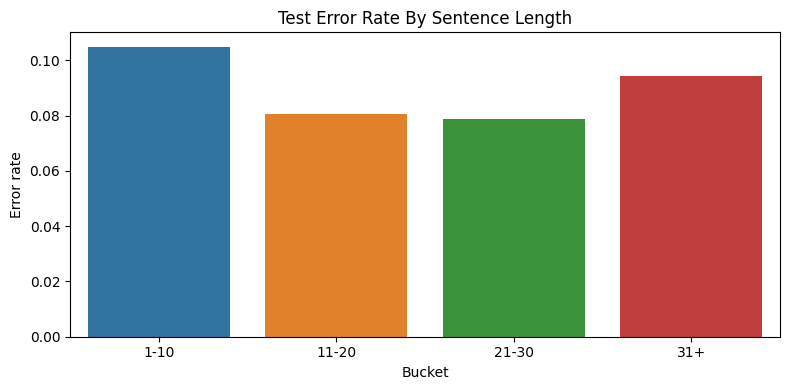

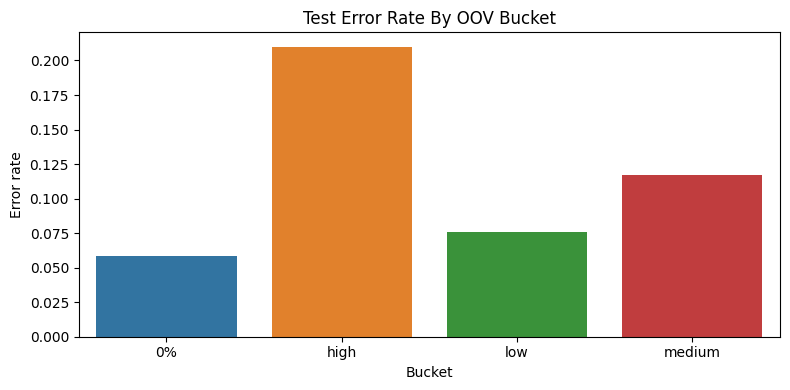

In [10]:
plot_single_model_buckets(model_run, comparison_split)


## Intermediate Conclusion: Robustness Pattern

The robustness plots show that HMM degrades more clearly than the stronger alternatives on difficult inputs. This is consistent with its dependence on fixed transition and emission statistics.


## Detailed Diagnostics


HMM + Viterbi | split = test


,model,split,token_accuracy,macro_f1,train_time_s,inference_time_s,tokens_per_second,model_size_mb,num_sentences,num_tokens,interpretability,implementation_complexity
0,hmm_viterbi,test,0.911294,0.840027,0.101,2.8858,8695.58,0.6275,2077,25094,high,low


Top tag confusions


,gold_tag,predicted_tag,count
0,PROPN,NOUN,375
1,NOUN,PROPN,161
2,VERB,AUX,105
3,VERB,NOUN,90
4,NOUN,VERB,83
5,ADJ,NOUN,82
6,SCONJ,ADP,78
7,ADV,ADJ,57
8,ADJ,VERB,55
9,ADV,ADP,53


Best and worst per-tag F1


,tag,precision,recall,f1,support
4,CCONJ,0.994550,0.991848,0.993197,736
12,PUNCT,0.970032,0.993217,0.981487,3096
10,PRON,0.964286,0.973198,0.968721,2164
5,DET,0.956950,0.972588,0.964706,1897
3,AUX,0.921808,0.977965,0.949057,1543
1,ADP,0.912899,0.947160,0.929714,2025
9,PART,0.907353,0.950693,0.928518,649
15,VERB,0.915221,0.890979,0.902937,2605


,tag,precision,recall,f1,support
7,NOUN,0.861188,0.899830,0.880085,4123
0,ADJ,0.891267,0.861857,0.876315,1788
2,ADV,0.884383,0.860621,0.872340,1191
6,INTJ,0.898990,0.735537,0.809091,121
11,PROPN,0.841045,0.744578,0.789877,2075
14,SYM,0.716535,0.805310,0.758333,113
13,SCONJ,0.790274,0.677083,0.729313,384
16,X,0.333333,0.023810,0.044444,42


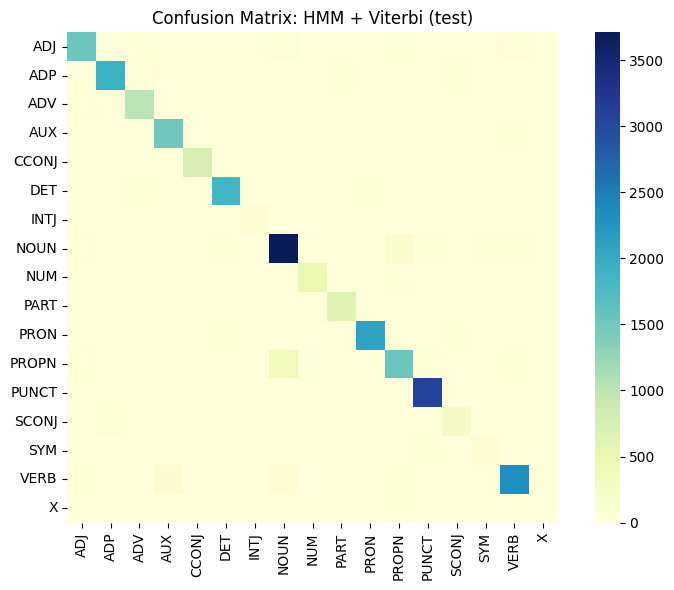

Representative error examples


,sentence_id,oov_rate,length_bucket,oov_bucket,mismatches
0,weblog-blogspot.com_aggressivevoicedaily_20060...,0.1316,31+,medium,"[{'token': 'to', 'gold': 'ADP', 'pred': 'PART'..."
1,newsgroup-groups.google.com_HumorUniversity_00...,0.3421,31+,high,"[{'token': 'Twinkle', 'gold': 'VERB', 'pred': ..."
2,email-enronsent18_01-0017,0.5526,31+,high,"[{'token': 'Consultant', 'gold': 'NOUN', 'pred..."


In [11]:
render_model_diagnostics(model_run, comparison_split)


## Intermediate Conclusion: Error Profile

The HMM notebook makes one model-specific limitation especially visible: the distinctive `VERB -> AUX` confusion. Together with the large `PROPN -> NOUN` counts, this suggests that the model is too rigid in the places where lexical ambiguity and unseen evidence matter most.


## Notebook Scope

This notebook contains the full run for this single model: data reload, training, evaluation, plots, and qualitative error inspection.
